# S&P 500 Equity+Options: Backtest and Signal Evaluation

**Chapter 16 - Strategy Simulation**

This notebook translates validation predictions into weekly, long-only equity
portfolios and evaluates the equal-weight top-$K$ baseline. Option-derived
features are predictive inputs only; the strategy trades equities.

**Learning objectives**

- verify decision-at-close and next-open execution with a random-signal smoke test;
- sweep equal-weight top-5, top-10, and top-20 portfolios for the primary label;
- rank only prediction sets with comparable validation-date coverage;
- interpret bootstrap and selection-adjusted uncertainty without opening the holdout.

Sections 1-2 register only missing primary-label baselines. Section 3 is
read-only and evaluates all five labels already present in the registry.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** completed validation predictions from Chapters 11-15 and
the case-study protocol in `config/setup.yaml`.

In [1]:
"""Ch16 backtest and signal evaluation for S&P 500 equity and option features."""

import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.notebook_render import selection_adjusted_leader_table
from case_studies.utils.registry import (
    backtest_dir,
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_entry_schemes_for,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
SPLIT = "validation"
TOP_K = 0  # 0 = use smallest top_k from setup.yaml backtest.sweep.top_k_grid
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Setup & Plumbing Test

The protocol forms signals at Friday's close and submits orders for the next
available open, normally Monday. This event ordering prevents Friday-close
features from receiving a same-bar fill. A seeded random-signal run is a
plumbing smoke test: it can detect gross engine bias, but it cannot prove that
every research choice is unbiased.

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

print(f"""Protocol term sheet
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

Protocol term sheet
  Case study:    sp500_equity_option_analytics
  Label:         fwd_ret_5d
  Calendar:      NYSE
  Cadence:       weekly_friday_close
  Commission:    3.9 bps
  Slippage:      2.6 bps
  Total cost:    6.5 bps/leg
  Long/short:    False



In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
if TOP_K == 0:
    _feasible_top_k = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
    if not _feasible_top_k:
        raise ValueError(
            f"top_k_grid for {LABEL!r} in {CASE_STUDY_ID} has no value < "
            f"n_assets={n_assets}; declare a feasible k in setup.yaml"
        )
    TOP_K = _feasible_top_k[0]
print(
    f"Price support: {len(prices):,} rows across {n_assets} historical symbols; "
    f"plumbing-test top-K={TOP_K}"
)

Price support: 250,916 rows across 554 historical symbols; plumbing-test top-K=5


In [6]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=TOP_K,
        seed=SEED,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")

    if abs(random_sharpe) >= 1.5:
        print("WARNING: random signal produces non-trivial Sharpe; inspect the pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: 0.716  [PASS]


## 2. Parametric Sweep

Sweep all primary-label prediction and concentration combinations through the
same `run_backtest()` function used for a single strategy. The sweep stores
every non-degenerate prediction result; the analysis below applies the stricter
maximum-coverage eligibility rule before ranking candidates.

The top-$K$ grid isolates concentration while holding sizing constant at equal
weight. Weekly top-5, top-10, and top-20 portfolios reveal whether a ranking
signal survives as the selected tail broadens.

In [7]:
pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)

if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  Fold-aggregate IC range: {ic_min:.4f} to {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 90
  Fold-aggregate IC range: -0.0151 to 0.0157


In [8]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

total_backtests = n_predictions * n_schemes
print(
    f"\nTotal grid: {n_predictions} predictions × {n_schemes} schemes = {total_backtests} backtests"
)


Entry schemes (3):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)

Total grid: 90 predictions × 3 schemes = 270 backtests


For each prediction set, content-addressed hashes identify concentration
variants already present in the registry. Only missing specifications need
execution.

In [9]:
def _artifact_matches_prediction_window(backtest_hash, predictions):
    artifact = backtest_dir(CASE_STUDY_ID, backtest_hash) / "daily_returns.parquet"
    if not artifact.exists():
        return False
    expected = predictions.select(pl.col("timestamp").cast(pl.Date).unique().sort())
    observed = pl.read_parquet(artifact).select(pl.col("timestamp").cast(pl.Date).unique().sort())
    return observed.equals(expected)


def _pending_specs(pred_row, predictions):
    pending = []
    n_existing = 0
    pred_hash = pred_row["prediction_hash"]
    for scheme in entry_schemes:
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            signal=signal,
        )
        backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        artifact_is_current = _artifact_matches_prediction_window(backtest_hash, predictions)
        if backtest_hash in existing_hashes and artifact_is_current:
            n_existing += 1
            continue
        pending.append((scheme, spec, backtest_hash in existing_hashes))
    return pending, n_existing

A single execution helper keeps the sweep cell focused on orchestration. It
returns the content hash on success and an error message on failure.

In [10]:
def _execute_one(pred_hash, spec, predictions, force_rebacktest):
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            prices=prices,
            predictions=predictions,
            label=LABEL,
            register=True,
            force_rebacktest=FORCE_REBACKTEST or force_rebacktest,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
    except Exception as exc:
        return None, str(exc)
    return result.backtest_hash, None

Progress counts include cached and newly executed combinations. A complete
registry therefore finishes quickly without reading every prediction parquet.

In [11]:
t0 = time.time()
completed = failed = skipped = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing equal-weight baseline hashes in registry: {len(existing_hashes):,}")

for pred_row in pred_index.iter_rows(named=True):
    pred_hash = pred_row["prediction_hash"]
    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))
    pending_schemes, n_existing = _pending_specs(pred_row, predictions)
    skipped += n_existing
    if not pending_schemes:
        continue

    for scheme, spec, force_rebacktest in pending_schemes:
        backtest_hash, error = _execute_one(pred_hash, spec, predictions, force_rebacktest)
        if error:
            failed += 1
            print(f"  FAILED {pred_row['source']} / {scheme['name']}: {error}")
        else:
            completed += 1
            existing_hashes.add(backtest_hash)

        processed = completed + failed + skipped
        if processed % 20 == 0 or processed == total_backtests:
            elapsed = time.time() - t0
            rate = processed / elapsed if elapsed > 0 else 0
            print(f"  [{processed}/{total_backtests}] {rate:.1f} bt/s | failed: {failed}")

elapsed = time.time() - t0
print(
    f"\nSweep complete: {completed} run in {elapsed:.0f}s "
    f"({failed} failed, {skipped} already complete)"
)

Existing equal-weight baseline hashes in registry: 627



Sweep complete: 0 run in 2s (0 failed, 270 already complete)


## 3. Signal Evaluation

This section is **read-only**. It evaluates the full registry across all five
labels, while the default sweep above covers only `fwd_ret_5d`. Eligibility
requires each prediction set to match the maximum validation-date coverage
within its family and label. This prevents a checkpoint scored on fewer dates
from winning on a different evaluation sample.

The holdout remains sealed. All ranks, intervals, and selection-adjustment
statistics in this notebook refer to validation data.

In [12]:
explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('sp500_equity_option_analytics', 1549 runs: allocation=735, cost_sensitivity=102, holdout=1, risk_overlay=84, signal=627)


### Eligible Leaders

Requiring maximum decision-date coverage within each family and label removes
partial prediction histories before ranking. The output below reports the
cross-label PCA leader on `fwd_ret_10d`, while the default primary label
advances a different, label-specific set of model configurations.

In [13]:
all_baselines = explorer.best(stage="signal", top_n=9999)
search_context = explorer.search_context(stage="signal")
top = all_baselines.head(10)

top_k = [
    explorer.inspect(backtest_hash).spec["strategy"]["signal"]["top_k"]
    for backtest_hash in top["backtest_hash"]
]
top = top.with_columns(pl.Series("top_k", top_k, dtype=pl.Int64))

leader_predictions = normalize_prediction_columns(
    read_predictions(CASE_STUDY_ID, top["prediction_hash"][0])
)
print(
    f"Eligible baselines: {search_context['total']:,}; "
    f"median Sharpe: {search_context['median_sharpe']:.3f}; "
    f"positive: {search_context['pct_positive']:.1f}%"
)
print(
    f"Leader coverage: {leader_predictions['symbol'].n_unique()} symbols across "
    f"{leader_predictions['timestamp'].n_unique()} validation dates"
)

top.select(
    "source",
    "label",
    "top_k",
    pl.col("sharpe").round(3),
    pl.col("ic_mean_daily").round(4).alias("daily_ic"),
    pl.col("cagr").round(3),
    pl.col("max_drawdown").round(3),
)

Eligible baselines: 627; median Sharpe: 0.308; positive: 90.7%
Leader coverage: 487 symbols across 492 validation dates


source,label,top_k,sharpe,daily_ic,cagr,max_drawdown
str,str,i64,f64,f64,f64,f64
"""latent_factors/pca""","""fwd_ret_10d""",5,1.512,0.0815,0.778,-0.415
"""latent_factors/pca""","""fwd_ret_10d""",10,1.373,0.0815,0.579,-0.383
"""latent_factors/pca""","""fwd_ret_10d""",20,1.349,0.0815,0.509,-0.347
"""latent_factors/pca""","""fwd_ret_risk_adj_5d""",20,1.208,0.0444,0.367,-0.32
"""latent_factors/pca""","""fwd_ret_risk_adj_5d""",10,1.068,0.0444,0.333,-0.348
"""latent_factors/pca""","""fwd_ret_risk_adj_5d""",5,0.974,0.0444,0.303,-0.363
"""deep_learning/nlinear""","""fwd_ret_5d""",5,0.826,0.0105,0.374,-0.542
"""deep_learning/nlinear""","""fwd_ret_5d""",10,0.812,0.0105,0.32,-0.482
"""latent_factors/sdf""","""fwd_ret_5d""",5,0.809,0.0032,0.279,-0.387


Downstream selection is label-specific and admits one checkpoint per distinct
model configuration. For `fwd_ret_5d`, NLinear leads at Sharpe 0.826; the
cross-label PCA result does not displace that primary-label lineage.

In [14]:
primary_advancing = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    top_n=10,
    stage="signal",
)
primary_advancing.select(
    "family",
    "config_name",
    "checkpoint_value",
    pl.col("sharpe").round(3),
)

family,config_name,checkpoint_value,sharpe
str,str,i64,f64
"""deep_learning""","""nlinear""",5,0.826
"""latent_factors""","""sdf""",-3,0.809
"""linear""","""lasso_f0.85""",null,0.711
"""linear""","""enet_f0.85""",null,0.706
"""latent_factors""","""cae""",50,0.692
"""latent_factors""","""ipca""",0,0.65
"""deep_learning""","""lstm_h64""",25,0.646
"""linear""","""lasso_f0.7""",null,0.595
"""linear""","""enet_f0.7""",null,0.584


### Family Dispersion and IC Translation

Family medians occupy a narrow Sharpe band, but PCA creates a much higher
latent-factor maximum. Across all eligible baselines, daily-pooled IC has only
a moderate rank association with portfolio Sharpe. Concentration, turnover,
and return-path differences therefore remain material after model ranking
quality is known. The figure reports the current coefficient from the registry.

In [15]:
families = explorer.compare_families(stage="signal")
ic_sharpe_rho = all_baselines.select(
    pl.corr("ic_mean_daily", "sharpe", method="spearman").alias("rho")
).item()

family_plot = families.sort("sharpe_median")
y_pos = list(range(family_plot.height))
family_labels = [name.replace("_", " ").title() for name in family_plot["family"]]

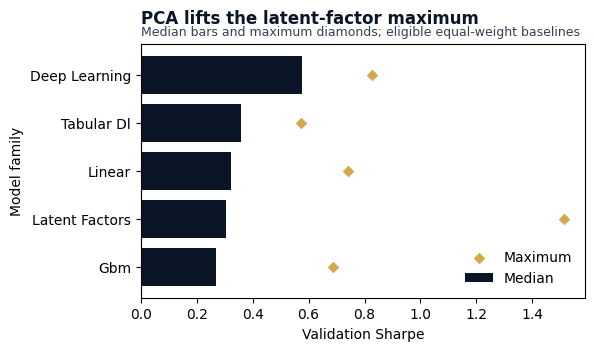

In [16]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.barh(y_pos, family_plot["sharpe_median"], color=COLORS["blue"], label="Median")
ax.scatter(
    family_plot["sharpe_max"],
    y_pos,
    color=COLORS["amber"],
    marker="D",
    s=24,
    label="Maximum",
    zorder=3,
)
ax.set_yticks(y_pos, family_labels)
ax.set_xlabel("Validation Sharpe")
ax.set_ylabel("Model family")
zero_line(ax, axis="x")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "PCA lifts the latent-factor maximum",
    "Median bars and maximum diamonds; eligible equal-weight baselines",
)
fig.show()

The same evaluation surface shows why prediction and portfolio diagnostics
cannot substitute for one another: similar IC values map to a wide Sharpe
range after tail selection and trading mechanics.

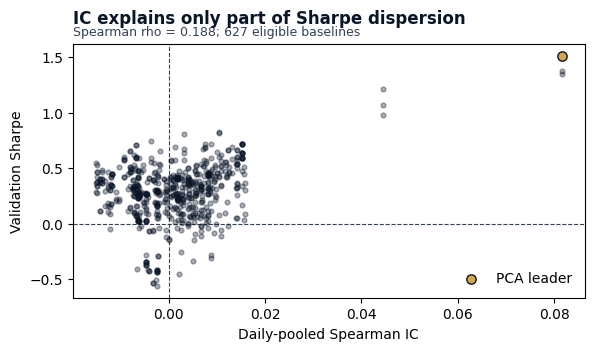

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.scatter(
    all_baselines["ic_mean_daily"],
    all_baselines["sharpe"],
    color=COLORS["blue"],
    alpha=0.35,
    s=12,
)
ax.scatter(
    top["ic_mean_daily"][0],
    top["sharpe"][0],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=45,
    zorder=3,
    label="PCA leader",
)
zero_line(ax, axis="x")
zero_line(ax, axis="y")
ax.set_xlabel("Daily-pooled Spearman IC")
ax.set_ylabel("Validation Sharpe")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "IC explains only part of Sharpe dispersion",
    f"Spearman rho = {ic_sharpe_rho:.3f}; {len(all_baselines):,} eligible baselines",
)
fig.show()

### Selection-Adjusted Uncertainty

A single-strategy bootstrap asks whether each return path clears zero. The
effective-rank deflated Sharpe ratio (DSR) additionally accounts for the
correlated variants tested within each family and label:

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right].$$

PCA is the only family leader whose block-bootstrap Sharpe interval excludes
zero: 1.512 `[0.158, 2.979]`. Its latent-factor cohort has six eligible
variants and an effective-rank DSR p-value of 0.0045. PBO equals 0.0, but it
is estimated from only two validation folds and therefore has very low
resolution. These diagnostics support a validation candidate, not an
out-of-sample claim.

In [18]:
family_leaders = selection_adjusted_leader_table(CASE_STUDY_ID, stage="signal")
family_leaders.select(
    "family",
    "config_name",
    "label",
    pl.col("sharpe").round(3),
    pl.col("sharpe_ci95_lo").round(3).alias("ci_lo"),
    pl.col("sharpe_ci95_hi").round(3).alias("ci_hi"),
    pl.col("dsr_pvalue").round(4),
    "k_variants",
    "pbo",
)

family,config_name,label,sharpe,ci_lo,ci_hi,dsr_pvalue,k_variants,pbo
str,str,str,f64,f64,f64,f64,i64,f64
"""latent_factors""","""pca""","""fwd_ret_10d""",1.512,0.158,2.979,0.0045,6,0.0
"""deep_learning""","""nlinear""","""fwd_ret_5d""",0.826,-0.434,2.203,null,null,null
"""linear""","""logistic_l1_C0.001""","""fwd_dir_10d""",0.742,-0.705,2.061,0.1554,30,1.0
"""gbm""","""leaves_15_mae""","""fwd_ret_risk_adj_5d""",0.688,-0.594,2.173,0.1132,45,0.5
"""tabular_dl""","""tabm_l""","""fwd_ret_5d""",0.574,-0.915,2.172,null,null,null


The interval plot separates the favorable PCA result from the other family
leaders, whose uncertainty still includes zero.

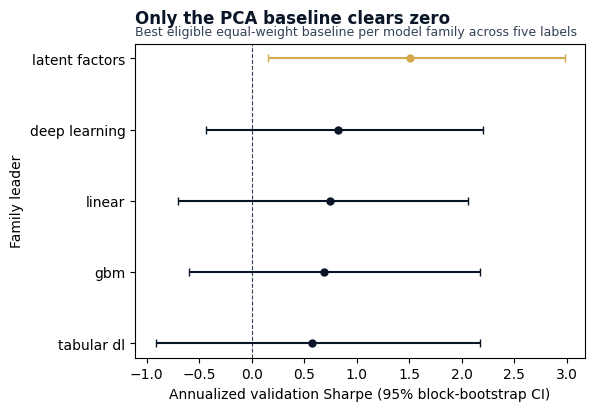

In [19]:
leader_plot = family_leaders.sort("sharpe")
leader_labels = [family.replace("_", " ") for family in leader_plot["family"]]

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
for i, row in enumerate(leader_plot.iter_rows(named=True)):
    focal = row["family"] == "latent_factors"
    color = COLORS["amber"] if focal else COLORS["blue"]
    ax.errorbar(
        row["sharpe"],
        i,
        xerr=[
            [row["sharpe"] - row["sharpe_ci95_lo"]],
            [row["sharpe_ci95_hi"] - row["sharpe"]],
        ],
        fmt="o",
        color=color,
        capsize=3,
        markersize=5,
    )
ax.set_yticks(range(leader_plot.height), leader_labels)
ax.set_xlabel("Annualized validation Sharpe (95% block-bootstrap CI)")
ax.set_ylabel("Family leader")
zero_line(ax, axis="x")
add_message_title(
    ax,
    "Only the PCA baseline clears zero",
    "Best eligible equal-weight baseline per model family across five labels",
)
fig.show()

### Downstream Preview

The best result at each available pipeline layer for the PCA prediction rises
from Sharpe 1.512 under equal weights to 1.685 after allocation. This is a
best-per-layer preview, not a fixed-spec causal attribution: each row selects
the strongest registered variant for the same prediction set.

In [20]:
stage_labels = {
    "signal": "equal-weight baseline",
    "allocation": "allocation",
    "cost_sensitivity": "cost sensitivity",
    "risk_overlay": "risk overlay",
}
best_pred = top["prediction_hash"][0]
progression = explorer.progression(best_pred)
progression.with_columns(
    pl.col("stage").replace_strict(stage_labels, default=pl.col("stage")).alias("pipeline_layer")
).select(
    "pipeline_layer",
    pl.col("sharpe").round(3),
    pl.col("cagr").round(3),
    pl.col("max_drawdown").round(3),
)

pipeline_layer,sharpe,cagr,max_drawdown
str,f64,f64,f64
"""equal-weight baseline""",1.512,0.778,-0.415
"""allocation""",1.685,0.921,-0.407
"""cost sensitivity""",1.697,0.931,-0.407
"""risk overlay""",2.39,0.98,-0.129


## Key Takeaways

1. Coverage-aware ranking removes partial prediction histories before
   comparing registered equal-weight baselines. PCA on `fwd_ret_10d`, top 5,
   leads with validation Sharpe 1.512 `[0.158, 2.979]` and daily-pooled IC
   0.0815 `[0.0497, 0.1134]`.
2. The PCA family cohort contains six eligible variants. Effective-rank DSR
   remains significant (p = 0.0045), while two-fold PBO is 0.0 and too
   coarse to support a strong stability claim.
3. The primary `fwd_ret_5d` pipeline remains separate: NLinear leads its eligible
   configuration set at Sharpe 0.826. Downstream selection never mixes labels.
4. IC and Sharpe are related but far from equivalent across the sweep;
   portfolio construction still changes the ranking. The current coefficient
   is reported directly in the figure rather than frozen into the prose.
5. The holdout remains sealed. The current-constituent universe also embeds
   survivorship bias, so these validation results are research evidence rather
   than a prospective performance estimate.

**Next:** `15_portfolio_management` compares equal weight, score weighting,
inverse volatility, risk parity, HRP, MVO, and conformal weighting within each
label-specific lineage.